## Complete grain size and shape analysis with ImageGrains 2.0 and Cellpose-SAM

This notebook demonstrates how to segment and measure grains in your images, saved in Google Drive.
This notebook follows the examples of [Cellpose-SAM](https://github.com/MouseLand/cellpose/tree/main/notebooks), inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki).
More details are found here: [code](https://github.com/dmair1989/imagegrains), [paper]().

### 1 - Ensure GPU access

"Change runtime type"; Change "Hardware accelerator" to GPU.
<div>
<img src="https://raw.githubusercontent.com/dmair1989/imagegrains/86bce6379bb965fa255a7de269ca8baa6ccad3a8/illustrations/colab/colab1.png" width="650"/>
</div>


### 2 - Mount your Google Drive
Run this cell, connect your Drive and grant access to your Google Drive
<div>
<img src="https://raw.githubusercontent.com/dmair1989/imagegrains/86bce6379bb965fa255a7de269ca8baa6ccad3a8/illustrations/colab/colab2.png" width="450"/>
</div>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Your folders should now be available after (after refreshing). Copy the path to the folder you want to use (and paste it in the corresponding cell below).
<div>
<img src="https://raw.githubusercontent.com/dmair1989/imagegrains/86bce6379bb965fa255a7de269ca8baa6ccad3a8/illustrations/colab/colab3.png" width="500"/>
</div>

### 3 - Install ImageGrains

In [ ]:
!pip install git+https://github.com/dmair1989/imagegrains.git

  Cloning https://github.com/dmair1989/imagegrains.git to /tmp/pip-req-build-wht7pibd
  Running command git clone --filter=blob:none --quiet https://github.com/dmair1989/imagegrains.git /tmp/pip-req-build-wht7pibd
  Resolved https://github.com/dmair1989/imagegrains.git to commit d06a3086b4807a9314742f75dc97c107a8355507
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.2/212.2 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 21.3 MB/s et

In [ ]:
import os
from imagegrains import grainsizing, plotting, segmentation_helper, data_loader, gsd_uncertainty
from cellpose import io
import pandas as pd
import matplotlib.pyplot as plt

### 4 - Download Default Model and Demo Data

In [ ]:
#Specify the target folder where the demo data and model weights will be stored.
#Store on your drive to avoid downloading the large model file more than once.
target_path = '/content/drive/MyDrive'

#Download the data and models.
download_path = data_loader.download_files(tar_path=target_path)

>> Downloading demo data to /content/drive/MyDrive ...
>> Using cached model weights from: /content/drive/MyDrive/models/IG2_full_set_cp_SAM


In [ ]:
#ascertain Cellpose version
try:
    from imagegrains import __cp_version__
except:
    __cp_version__ = 2

#set path to default model based on Cellpose version
# ** 'model_path' and 'model_id' can be changed to use custom models **
if __cp_version__ < 4:
    model_path = f'{download_path}/models/IG2_full_set.200525'
    model_id = 'IG2_full_set'
elif __cp_version__ >= 4:
    model_path = f'{download_path}/models/IG2_full_set_cp_SAM'
    model_id = 'IG2_full_set_cp_SAM'

### 5 - Segment images in a folder


In [ ]:
#specify the folder with images to segment
# ** Paste the Path you copied before **
image_path = '/content/drive/MyDrive/demo_data/K1'

In [ ]:
#run segmentation (and save the prediction masks)
segmentation_helper.predict_dataset(image_path,model_path,mute=True,return_results=False,save_masks=True,use_gpu=True);

/content/drive/MyDrive/demo_data/K1: 100%|██████████| 2/2 [00:45<00:00, 22.58s/image]


### Optional: Load predictions masks and plot them

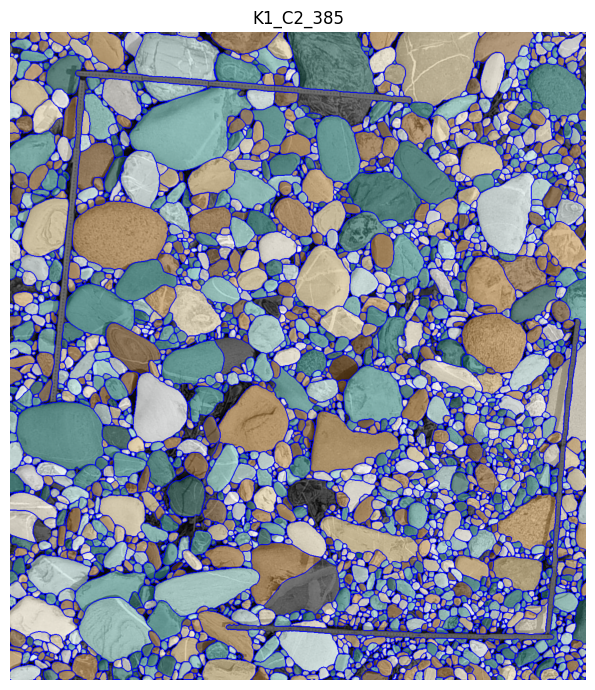

In [ ]:
#get paths to image and segmentation masks...
imgs,_,preds = data_loader.dataset_loader(image_path,pred_str='pred')
#... and plot them for the first image in the folder
plt.figure(figsize=(7,7))
plotting.plot_single_img_pred(imgs[0],preds[0],show=True)

### Optional: Filter and resample masks

In [ ]:
#load the segmentation masks from file
masks = io.imread(preds[0])
#define the filters to apply to the segmentation masks
filters= {'edge':[True,.21],'px_cutoff':[True,8]}
#resample masks and apply the filters
grid_resampled,xx,yy = grainsizing.resample_masks(masks,filters=filters,grid_size=18,mute=False)
#save resampled mask
io.imsave(f'{image_path}/K1_C2_385_resampled_pred.tif',grid_resampled)


image shape: 1200 x 1350
number of Wolman nodes: 39 x 44


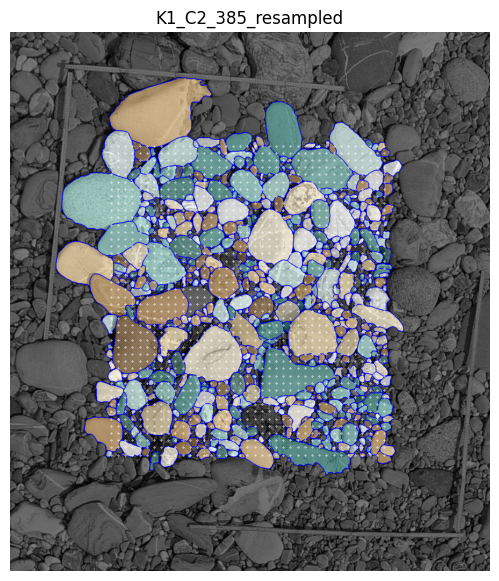

In [ ]:
#plot resampled mask
plt.figure(figsize=(7,7))
plotting.plot_single_img_mask(io.imread(imgs[0]),grid_resampled,file_id='K1_C2_385_resampled')
#plot resampling grid
plt.scatter(yy,xx,marker='.',color='w',s=0.5);

### 6 - Measure grain properties

In [ ]:
#measure the grains and save the results
# **remove "mask_str='resampled' to mmeasure all results, nut just the resampled grains
grains,grains_props,grain_id = grainsizing.batch_grainsize(image_path,mask_str='resampled',mute=True,return_results=True)

/content/drive/MyDrive/demo_data/K1: 100%|██████████| 1/1 [00:01<00:00,  1.69s/file]


### Optional: Convert from pixel to length units

In [ ]:
#set the resolution in mm/px
resolution = 0.39
#scale with the image resolution and save the results
grainsizing.re_scale_dataset(image_path,resolution=resolution,gsd_str='_grains',save_gsds=True);

### Optional: Plot measured grains

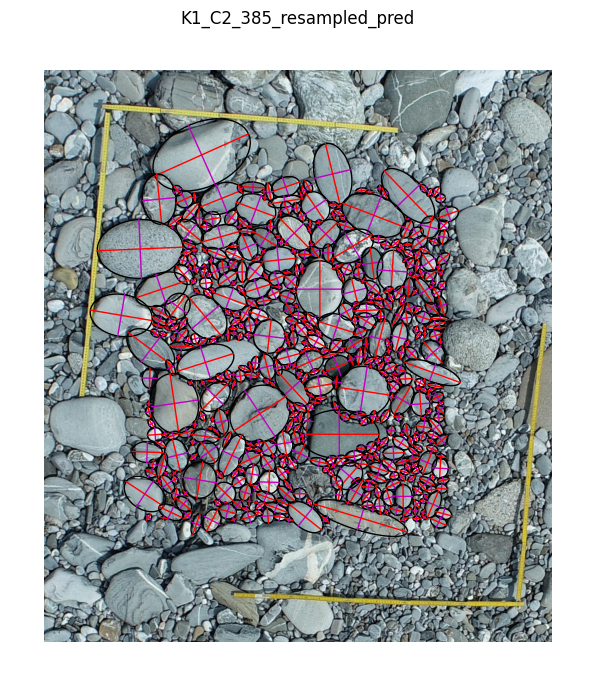

In [ ]:
#define plot elements
elements= ['image','ellipse','ellipse_b','ellipse_a']
#plot
plt.figure(figsize=(7,7))
plotting.all_grains_plot(grid_resampled,props=grains_props[0],elements=elements,image=io.imread(imgs[0]),title=grain_id[0])

In [ ]:
#load example grain results
grains_df = pd.read_csv('/content/drive/MyDrive/demo_data/K1/predictions/K1_C2_385_resampled_pred_grains_re_scaled.csv')
grains_df.head()

,label,area,area_convex,perimeter_crofton,orientation,ell: b-axis (px),ell: a-axis (px),centerpoint y,centerpoint x,convexity,...,local centerpoint x,bbox y1,bbox x1,bbox y2,bbox x2,IR,IRn,b axis azimuth (deg),ell: a-axis (mm),ell: b-axis (mm)
0,1,27491.0,30105.0,721.173021,-1.148374,152.129717,242.763382,199.622822,372.697283,0.913171,...,124.697283,114,248,289,504,0.66,0.72,155.797011,94.677719,59.330590
1,2,9977.0,10225.0,379.404773,0.236111,86.689931,147.302427,244.517390,682.297484,0.975746,...,44.297484,174,638,316,730,0.87,0.97,76.471839,57.447947,33.809073
2,3,9662.0,10347.0,412.352027,0.765131,77.770278,162.649239,296.215794,860.548644,0.933797,...,62.548644,226,798,360,932,0.71,0.87,46.161238,63.433203,30.330409
3,4,7382.0,7564.0,327.384696,0.098259,79.497811,118.936341,304.140341,272.424275,0.975939,...,42.424275,247,230,367,312,0.87,0.92,84.370190,46.385173,31.004146
4,5,2452.0,2544.0,186.398132,-1.238354,45.741779,69.076503,275.107667,571.179445,0.963836,...,32.179445,252,539,300,605,0.89,0.94,160.952430,26.939836,17.839294


### 7 - Grain size distribution and uncertainty

In [ ]:
f'{image_path}/predictions/'

'/content/drive/MyDrive/demo_data/K1/predictions/'

In [ ]:
#load the resampled grains
grains_scaled = data_loader.load_grain_set(image_path,gsd_str='resampled_pred_grains_re_scaled')
#calculate the gsd for one column (e.g. b-axis with ellispe fit)
column_name = 'ell: b-axis (mm)'
#set uncertainty method
method = 'bootstrapping'
#path for uncertainty output
target_path='/content/drive/MyDrive/demo_data/K1/GSD_uncertainty'
#calculate the gsd and uncertainty and save the results
res_dict_bs = gsd_uncertainty.dataset_uncertainty(gsds=grains_scaled,num_it=1000,method=method,mute=True,column_name=column_name,
                                                  save_results=True,tar_dir=target_path,return_results=True,sep=',',gsd_id=grain_id)

ell: b-axis (mm) bootstrapping: 100%|██████████| 1/1 [00:01<00:00,  1.41s/gsd]


In [ ]:
# calculate and save key percentile summary
summary_df = grainsizing.summary_statistics(grains_scaled,grain_id,res_dict=res_dict_bs,data_id=grain_id[0],key_perc=[16,50,84,96],save_summary=True)
summary_df.head()

,Image/Masks,number of grains,D16,D50,D84,D96,CI D16 (95%),CI D50 (95%),CI D84 (95%),CI D96 (95%),unit,axis,method,grain approximation
0,K1_C2_385_resampled_pred,539,10.8,16.8,32.3,69.7,[4. 4.4],[6.3 7.1],[11. 14.1],[21.6 30.1],mm,b-axis,bootstrapping,ellipse


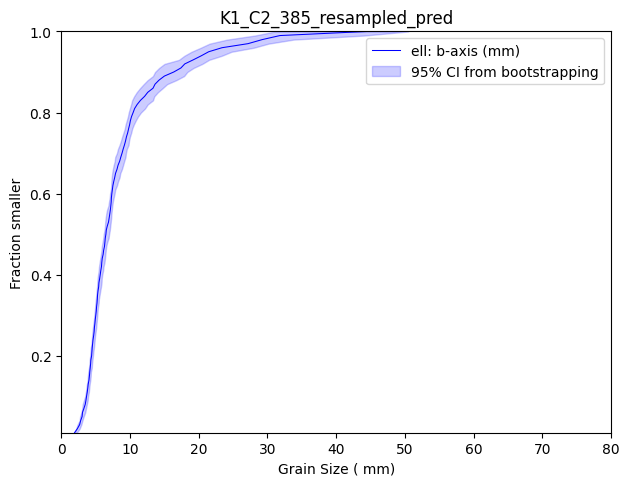

In [ ]:
#plot gsd
plotting.plot_gsd(res_dict_bs[grain_id[0]][3],color='b',length_max=80,orientation='vertical',label_axes=True,units= 'mm')
#plot uncertainty
plotting.plot_gsd_uncert(res_dict_bs[grain_id[0]],color='b')
plt.legend([column_name,f'95% CI from {method}'])
plt.title(grain_id[0]);